In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv('matches - matches.csv')

In [3]:
df.info
df.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
count,636.000000,636.000000,636.000000,636.000000,636.000000,0.0
mean,318.500000,2012.490566,0.025157,13.682390,3.372642,NaN
std,183.741666,2.773026,0.156726,23.908877,3.420338,NaN
min,1.000000,2008.000000,0.000000,0.000000,0.000000,NaN
25%,159.750000,2010.000000,0.000000,0.000000,0.000000,NaN
50%,318.500000,2012.000000,0.000000,0.000000,4.000000,NaN
75%,477.250000,2015.000000,0.000000,20.000000,7.000000,NaN
max,636.000000,2017.000000,1.000000,146.000000,10.000000,NaN


In [4]:
df.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [5]:
df['city'] = df['city'].fillna(0)
df.drop(columns=['umpire3'], axis=1, inplace=True)
df.dropna(subset=['winner', 'player_of_match', 'umpire1', 'umpire2'], inplace=True)

In [6]:
df.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

0

In [10]:
import matplotlib.pyplot as plt

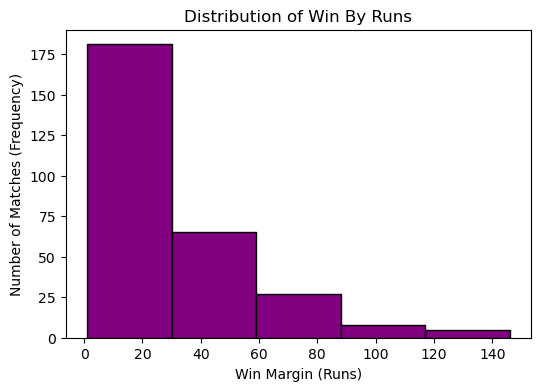

In [18]:
actual_win_by_runs = df[df['win_by_runs'] > 0]['win_by_runs']

# 2. Plot your stylized histogram
plt.figure(figsize=(6, 4))
plt.hist(actual_win_by_runs, bins=5, color='purple', edgecolor='black')

# 3. Clean and accurate labeling
plt.xlabel('Win Margin (Runs)')
plt.ylabel('Number of Matches (Frequency)')
plt.title('Distribution of Win By Runs')

plt.show()

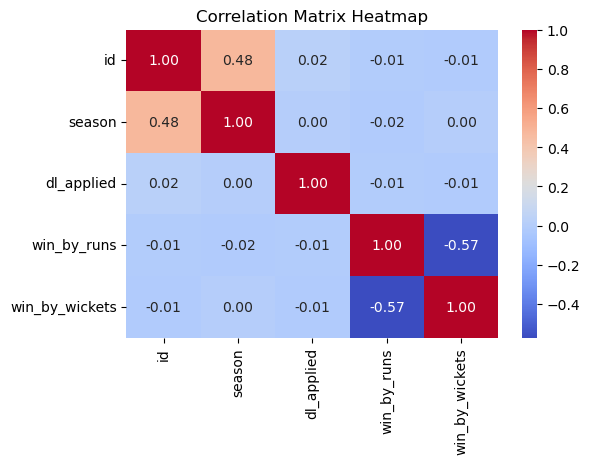

In [20]:
import seaborn as sns
plt.figure(figsize=(6, 4))
# df.corr() calculates the Pearson correlation between columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

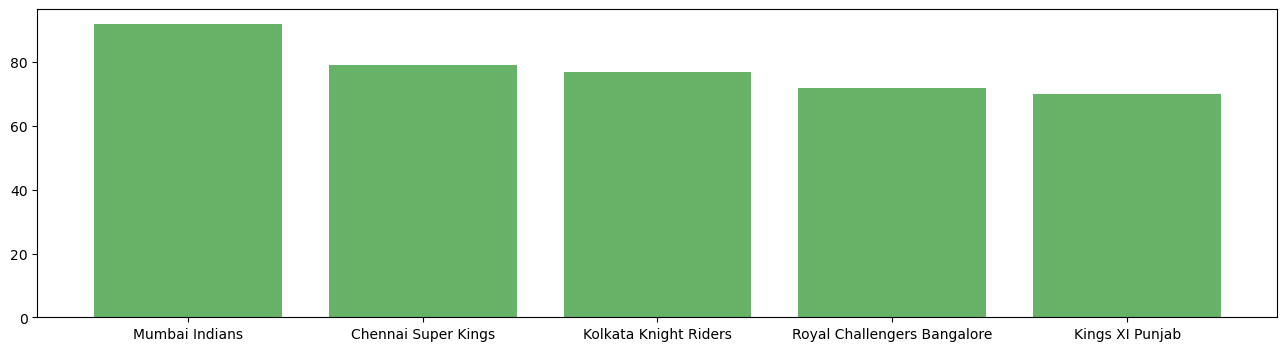

In [26]:
top_winners = df['winner'].value_counts().head(5)
plt.figure(figsize=(16, 4))
plt.bar(top_winners.index,top_winners.values, color='green', alpha=0.6)
plt.show()

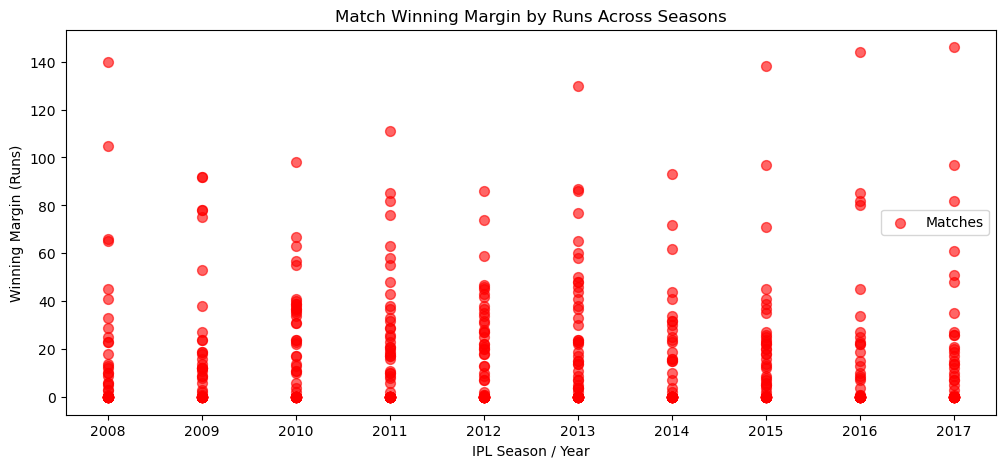

In [30]:
plt.figure(figsize=(12, 5))
plt.scatter(df['season'], df['win_by_runs'], color='red', s=50, alpha=0.6, label='Matches')
plt.xlabel('IPL Season / Year')
plt.ylabel('Winning Margin (Runs)')
plt.title('Match Winning Margin by Runs Across Seasons')
plt.xticks(df['season'].unique()) 

plt.legend()
plt.show()

C:\Users\vishe\AppData\Local\Temp\ipykernel_9728\2390011290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='win_by_runs', ax=axes[0], palette='pastel')
C:\Users\vishe\AppData\Local\Temp\ipykernel_9728\2390011290.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='season', y='win_by_runs', ax=axes[1], palette='pastel')


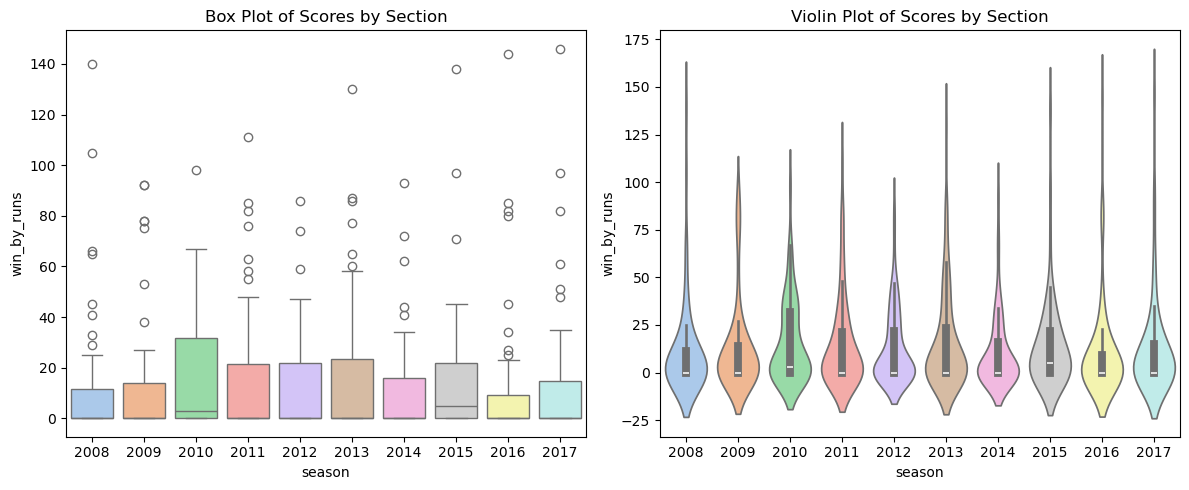

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='season', y='win_by_runs', ax=axes[0], palette='pastel')
axes[0].set_title('Box Plot of wins_by_runs in each season')
sns.violinplot(data=df, x='season', y='win_by_runs', ax=axes[1], palette='pastel')
axes[1].set_title('Violin Plot of wins_by_runs')

plt.tight_layout()
plt.show()